# NHL Momentum Prediction Pipeline 🏒
* **Author:** Brian Fortin
* **Date:** November 2025
* **Project Type:** End-to-End Machine Learning (ETL, Feature Engineering, XGBoost)

## Goal
To predict the probability of a Boston Bruins win ($P(Win)$) by modeling **Rolling Momentum** and **Schedule Fatigue**, quantifying how much recent form outweighs home-ice advantage.

## Part 1: ETL (Extract, Transform, and Load)

In [1]:
import requests
import pandas as pd

TEAM = 'BOS'
SEASONS = ['20222023', '20232024']
OUTPUT_FILE = 'bruins_data.csv'

def fetch_and_process_games(team_abbr, seasons):
    """
    Fetch JSON from NHL API, transfer specific fields to clean, return the list
    """
    all_games_clean = []

    for season in seasons:
        # web request
        url = f"https://api-web.nhle.com/v1/club-schedule-season/{team_abbr}/{season}"
        try:
            response = requests.get(url)
            response.raise_for_status()
            data = response.json()
        except Exception as e:
            print(f"Error fetching {team_abbr}{season}: {e}")
            continue

        # fetch games
        for game in data.get('games', []):
            # skip current and future games
            if 'score' not in game['homeTeam']:
                continue

            # determine home and away score
            if game['homeTeam']['abbrev'] == team_abbr:
                is_home = 1
                opponent_abbrev = game['awayTeam']['abbrev']
                goals_for = game['homeTeam']['score']
                goals_against = game['awayTeam']['score']
            else:
                is_home = 0
                opponent_abbrev = game['homeTeam']['abbrev']
                goals_for = game['awayTeam']['score']
                goals_against = game['homeTeam']['score']

            # 1 = win, 0 = loss
            win = 1 if goals_for > goals_against else 0

            all_games_clean.append({
                'date': game['gameDate'],
                'opponent': opponent_abbrev,
                'is_home': is_home,
                'goals_for': goals_for,
                'goals_against': goals_against,
                'win': win,
            })

    return all_games_clean

# execution
print(f"Fetching data for {TEAM}...")

# run fetch_and_process_games
clean_data = fetch_and_process_games(TEAM, SEASONS)

# load into pandas data frame
df = pd.DataFrame(clean_data)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# output to csv
try:
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"Output written to {OUTPUT_FILE}.")
    display(df.head(7))
    display(df.tail(7))
except Exception as e:
    print(f"Error writing to {OUTPUT_FILE}: {e}.")
    print(f"Close any open instances of the CSV.")

Fetching data for BOS...
Output written to bruins_data.csv.


,date,opponent,is_home,goals_for,goals_against,win
0,2022-09-24,PHI,0,1,2,0
1,2022-09-27,NYR,1,3,2,1
2,2022-10-01,PHI,1,4,0,1
3,2022-10-03,NJD,0,0,1,0
4,2022-10-05,NYR,0,5,4,1
5,2022-10-08,NJD,1,3,5,0
6,2022-10-12,WSH,0,5,2,1


,date,opponent,is_home,goals_for,goals_against,win
189,2024-05-04,TOR,1,2,1,1
190,2024-05-06,FLA,0,5,1,1
191,2024-05-08,FLA,0,1,6,0
192,2024-05-10,FLA,1,2,6,0
193,2024-05-12,FLA,1,2,3,0
194,2024-05-14,FLA,0,2,1,1
195,2024-05-17,FLA,1,1,2,0


## Part 2: Feature Engineering (Declaration of Variables)

In [2]:
import pandas as pd
import numpy as np

INPUT_FILE = 'bruins_data.csv'
OUTPUT_FILE = 'bruins_features.csv'

df = pd.read_csv(INPUT_FILE, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# declare model variables

# goal differential
df['goal_diff'] = df['goals_for'] - df['goals_against']

# momentum: 5-game goal differential sum
# .shift(1) to avoid using the given game's score to predict the given game's score
df['rolling_goal_diff'] = df['goal_diff'].rolling(window=5).sum().shift(1)

# fatigue: days of rest and back-to-backs
# days since last game
df['days_rest'] = df['date'].diff().dt.days
# if team played yesterday, days_rest = 1, count as back-to-back
df['is_btb'] = (df['days_rest'] == 1).astype(int)

# win streak
# identify where win changes (i.e. streak ends)
change_in_streak = df['win'] != df['win'].shift(1)

# define streak as a cumulative sum of streak changes
streak_id = change_in_streak.cumsum()
# count number of games in this streak group
df['streak_raw'] = df.groupby(streak_id).cumcount() + 1

# set loss streak to 0, keep win streak to its count
df['win_streak'] = np.where(df['win'] == 1, df['streak_raw'], 0)
# .shift(1) to not count current game
df['win_streak'] = df['win_streak'].shift(1).fillna(0)

# opponent strength
# strong teams are teams that made the playoffs in the 20222023 season, excluding BOS
strong_teams = [
    'TOR', 'TBL', 'CAR', 'NJD', 'NYR', 'NYI', 'FLA',
    'COL', 'DAL', 'MIN', 'VGK', 'EDM', 'LAK', 'SEA', 'WPG'
]

# create binary: 1 if strong, 0 if weak
df['is_strong_opponent'] = df['opponent'].apply(lambda x: 1 if x in strong_teams else 0)

# save
model_df = df.dropna().reset_index(drop=True)

model_df.to_csv(OUTPUT_FILE, index=False)

print(f"Output written to {OUTPUT_FILE}.")
display(model_df.head(7))
display(model_df.iloc[130:150])
display(model_df.tail(7))

Output written to bruins_features.csv.


,date,opponent,is_home,goals_for,goals_against,win,goal_diff,rolling_goal_diff,days_rest,is_btb,streak_raw,win_streak,is_strong_opponent
0,2022-10-08,NJD,1,3,5,0,-2,4.0,3.0,0,1,1.0,1
1,2022-10-12,WSH,0,5,2,1,3,3.0,4.0,0,1,0.0,0
2,2022-10-15,ARI,1,6,3,1,3,5.0,3.0,0,2,1.0,0
3,2022-10-17,FLA,1,5,3,1,2,4.0,2.0,0,3,2.0,1
4,2022-10-18,OTT,0,5,7,0,-2,7.0,1.0,1,1,3.0,0
5,2022-10-20,ANA,1,2,1,1,1,4.0,2.0,0,1,0.0,0
6,2022-10-22,MIN,1,4,3,1,1,7.0,2.0,0,2,1.0,1


,date,opponent,is_home,goals_for,goals_against,win,goal_diff,rolling_goal_diff,days_rest,is_btb,streak_raw,win_streak,is_strong_opponent
130,2023-12-31,DET,0,5,3,1,2,0.0,1.0,1,3,2.0,0
131,2024-01-02,CBJ,0,4,1,1,3,3.0,2.0,0,4,3.0,0
132,2024-01-04,PIT,1,5,6,0,-1,10.0,2.0,0,1,4.0,0
133,2024-01-06,TBL,1,7,3,1,4,10.0,2.0,0,1,0.0,1
134,2024-01-08,COL,0,3,4,0,-1,11.0,2.0,0,1,1.0,1
135,2024-01-09,ARI,0,3,4,0,-1,7.0,1.0,1,2,0.0,0
136,2024-01-11,VGK,0,1,2,0,-1,4.0,2.0,0,3,0.0,1
137,2024-01-13,STL,0,4,3,1,1,0.0,2.0,0,1,0.0,0
138,2024-01-15,NJD,1,3,0,1,3,2.0,2.0,0,2,1.0,1
139,2024-01-18,COL,1,5,2,1,3,1.0,3.0,0,3,2.0,1


,date,opponent,is_home,goals_for,goals_against,win,goal_diff,rolling_goal_diff,days_rest,is_btb,streak_raw,win_streak,is_strong_opponent
184,2024-05-04,TOR,1,2,1,1,1,1.0,2.0,0,1,0.0,1
185,2024-05-06,FLA,0,5,1,1,4,3.0,2.0,0,2,1.0,1
186,2024-05-08,FLA,0,1,6,0,-5,5.0,2.0,0,1,2.0,1
187,2024-05-10,FLA,1,2,6,0,-4,-2.0,2.0,0,2,0.0,1
188,2024-05-12,FLA,1,2,3,0,-1,-5.0,2.0,0,3,0.0,1
189,2024-05-14,FLA,0,2,1,1,1,-5.0,2.0,0,1,0.0,1
190,2024-05-17,FLA,1,1,2,0,-1,-5.0,3.0,0,1,1.0,1


## Part 3: Model Building (Logistic Regression (Baseline) versus XGBoost)

In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print(f"{"-"*10} LOGISTIC REGRESSION MODEL WITH TIME-SERIES SPLIT {"-"*10}")

# load data
df = pd.read_csv('bruins_features.csv', parse_dates=['date'])

# split data by NHL season
split_date = '2023-09-01'

train = df[df['date'] < split_date].copy()
test = df[df['date'] >= split_date].copy()

features = ['rolling_goal_diff', 'is_btb', 'win_streak', 'is_home', 'is_strong_opponent']
target = 'win'

# train the model on the first half, test its fit on the second half
# to mimic real predictive analysis
# x = features
# y = target
x_train = train[features]
y_train = train[target]
x_test = test[features]
y_test = test[target]

print(f"Training on {len(x_train)} games. Testing on {len(x_test)} games.")

# train model
model = LogisticRegression(class_weight='balanced', random_state=33)
model.fit(x_train, y_train)

# evaluate
predictions = model.predict(x_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model accuracy:  {accuracy:.1%}")
print(f"{"-"*10} CLASSIFICATION REPORT {"-"*10}")
# loss = 0, win = 1
print(classification_report(y_test, predictions, target_names=['Loss', 'Win']))

# interpretation
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

print(f"\n{"-"*10} INSIGHTS {"-"*10}")
print(coef_df)
print("+ Positive means it INCREASES the chance of winning")
print("- Negative means it DECREASES the chance of winning")



---------- LOGISTIC REGRESSION MODEL WITH TIME-SERIES SPLIT ----------
Training on 90 games. Testing on 101 games.
Model accuracy:  56.4%
---------- CLASSIFICATION REPORT ----------
              precision    recall  f1-score   support

        Loss       0.56      0.22      0.31        46
         Win       0.57      0.85      0.68        55

    accuracy                           0.56       101
   macro avg       0.56      0.54      0.50       101
weighted avg       0.56      0.56      0.51       101


---------- INSIGHTS ----------
              Feature  Coefficient
1              is_btb     0.075178
3             is_home     0.049943
2          win_streak    -0.018267
0   rolling_goal_diff    -0.043641
4  is_strong_opponent    -0.439645
+ Positive means it INCREASES the chance of winning
- Negative means it DECREASES the chance of winning


In [4]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

print(f"{"-"*10} XGBOOST WITH TIME-SERIES SPLIT {"-"*10}")

# load features
df = pd.read_csv('bruins_features.csv', parse_dates=['date'])

# split data by NHL season
split_date = '2023-09-01'

train = df[df['date'] < split_date].copy()
test = df[df['date'] >= split_date].copy()

features = ['rolling_goal_diff', 'is_btb', 'win_streak', 'is_home', 'is_strong_opponent']
target = 'win'

# train the model on the first half, test its fit on the second half
# to mimic real predictive analysis
# x = features
# y = target
x_train = train[features]
y_train = train[target]
x_test = test[features]
y_test = test[target]

print(f"Training on {len(x_train)} games. Testing on {len(x_test)} games.")

# train XGBoost
# n_estimators = 50 to prevent overfitting on small data
# max_depth = 3 to keep trees shallow
model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss', # evaluation metric
    random_state=33,
)
model.fit(x_train, y_train)

# evaluate with probability threshold
probabilities = model.predict_proba(x_test)[:, 1]

# reduce false positives by only predicting wins above 60% confidence
predictions = (probabilities > 0.60).astype(int)
accuracy = accuracy_score(y_test, predictions)
auc = roc_auc_score(y_test, probabilities)

print(f"New Accuracy: {accuracy:.1%}")
print(f"AUC Score: {auc:.3f}")

print(f"\n{"-"*10} MODEL 2 INSIGHTS {"-"*10}")

# loss = 0, win = 1
print(classification_report(y_test, predictions, target_names=['Loss', 'Win']))

# feature importance
feature_importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nKey Drivers of Wins")
print(feature_importance)

---------- XGBOOST WITH TIME-SERIES SPLIT ----------
Training on 90 games. Testing on 101 games.
New Accuracy: 59.4%
AUC Score: 0.606

---------- MODEL 2 INSIGHTS ----------
              precision    recall  f1-score   support

        Loss       0.73      0.17      0.28        46
         Win       0.58      0.95      0.72        55

    accuracy                           0.59       101
   macro avg       0.65      0.56      0.50       101
weighted avg       0.65      0.59      0.52       101


Key Drivers of Wins
is_home               0.319438
rolling_goal_diff     0.282849
win_streak            0.182124
is_strong_opponent    0.148375
is_btb                0.067214
dtype: float32


## Part 4: Visualization

Image saved to feature_importance.png


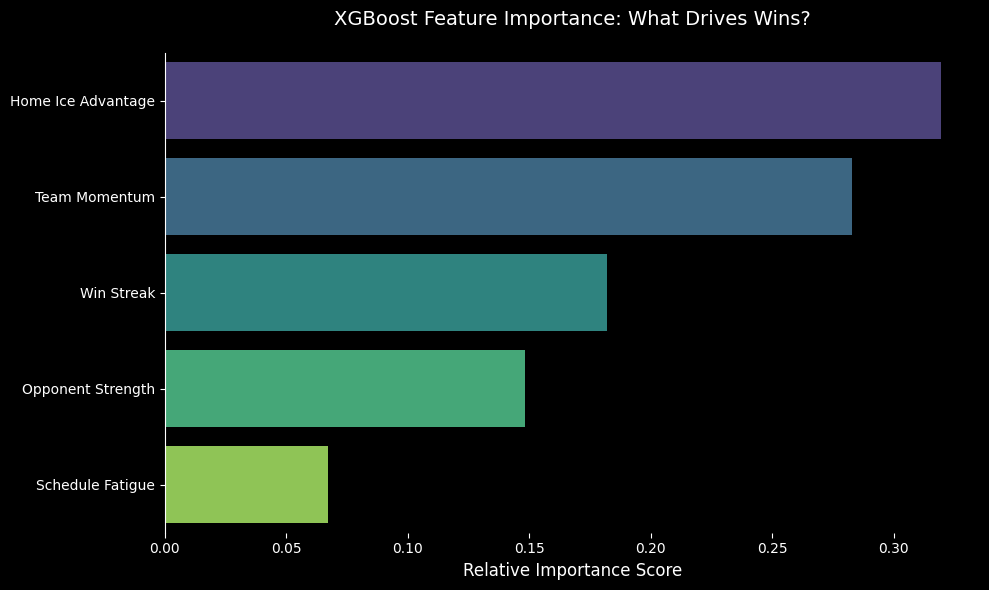

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_FILE = 'feature_importance.png'

# data from final XGBoost model
features = ['Home Ice Advantage', 'Team Momentum', 'Win Streak', 'Opponent Strength', 'Schedule Fatigue']
importance = [0.319438, 0.282849, 0.182124, 0.148375, 0.067214]

# create data frame
df_visual = pd.DataFrame({'Feature': features, 'Importance': importance})
df_visual = df_visual.sort_values('Importance', ascending=False)

# plot
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=df_visual,
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('XGBoost Feature Importance: What Drives Wins?', fontsize=14, pad=20)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('')
plt.xticks(color='white')
plt.yticks(color='white')
sns.despine(bottom=True)
plt.tight_layout()

# save
plt.savefig(OUTPUT_FILE, dpi=300)
print(f"Image saved to {OUTPUT_FILE}")
plt.show()